In [27]:
from agent import Agent
from data.read_data import read_data
import numpy as np
import matplotlib.pyplot as plt

data_dict = read_data()
K, L, num_links, num_agents, noise_covariance, dt, initial_positions, target_positions = data_dict.values()

In [29]:
from simulation import SimulationConfig, Simulation
from filters import MovingAverageFilter, NoOpFilter

configurations = [  SimulationConfig(noise_covariance=noise_covariance * 200,
                                    filter=NoOpFilter(),
                                    desc='Noise, no filter',
                                    dt=dt),
                    SimulationConfig(noise_covariance=np.zeros_like(noise_covariance),
                                    filter=NoOpFilter(),
                                    desc='No Noise',
                                    dt=dt),
                    SimulationConfig(noise_covariance=noise_covariance * 200,
                                     filter=MovingAverageFilter(window_size=2),
                                     desc='Moving Average, Filter Size 2',
                                     dt=dt),
                    SimulationConfig(noise_covariance=noise_covariance * 200,
                                   filter=MovingAverageFilter(window_size=5),
                                   desc='Moving Average, Filter Size 5',
                                   dt=dt),
                    SimulationConfig(noise_covariance=noise_covariance * 200,
                                    filter=MovingAverageFilter(window_size=20),
                                    desc='Moving Average, Filter Size 20',
                                    dt=dt),
                    SimulationConfig(noise_covariance=noise_covariance * 200,
                                    filter=MovingAverageFilter(window_size=200),
                                    desc='Moving Average, Filter Size 200',
                                    dt=dt)
                  ]

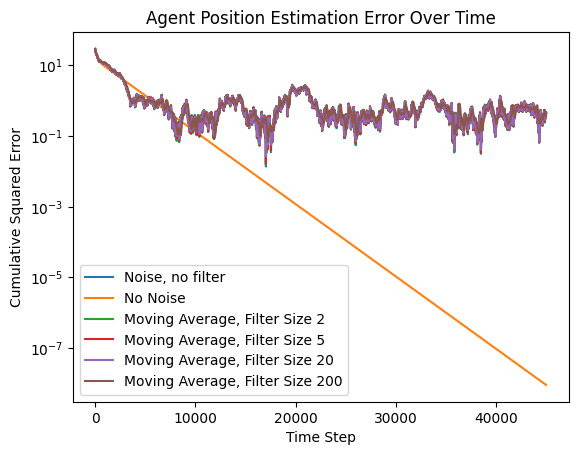

In [30]:
plt.figure()
seed = np.random.randint(0, 100000)

for config in configurations:
    agents = [Agent(id=i, initial_position=initial_positions[i], target_position=target_positions[i], filter=config.filter) for i in range(num_agents)]
    
    sim = Simulation(agents=agents, L=L, config=config, seed=seed)
    errors = sim.run(num_steps=K)
    plt.plot(errors, label=config.desc)
    
plt.xlabel('Time Step')
plt.ylabel('Cumulative Squared Error')
plt.yscale('log')
plt.legend()
plt.title('Agent Position Estimation Error Over Time')
plt.show()